## 📥 ETAP 0: Pozyskanie danych

**Cel:** przygotowanie surowych danych do analizy  

### Import bibliotek

In [2]:
import pandas as pd
import numpy as nb
import matplotlib.pyplot as plt
import seaborn as sns

### Wczytanie danuch

In [3]:
df_customers = pd.read_csv('dane/olist_customers_dataset.csv')
df_geolocation = pd.read_csv('dane/olist_geolocation_dataset.csv')
df_order_items = pd.read_csv('dane/olist_order_items_dataset.csv')
df_order_payments = pd.read_csv('dane/olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv('dane/olist_order_reviews_dataset.csv')
df_orders = pd.read_csv('dane/olist_orders_dataset.csv')
df_products = pd.read_csv('dane/olist_products_dataset.csv')
df_sellers = pd.read_csv('dane/olist_sellers_dataset.csv')
df_category_names = pd.read_csv('dane/product_category_name_translation.csv')

In [4]:
print(df_customers.head())
print(df_geolocation.head())
print(df_order_items.head())
print(df_order_payments.head())
print(df_order_reviews.head())
print(df_orders.head())
print(df_products.head())
print(df_sellers.head())
print(df_category_names.head())

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.639292   
1                

### Łącznie danych

In [5]:
df = df_orders.merge(df_customers, on='customer_id', how='left')
df = df.merge(df_order_items, on='order_id', how='left')
df = df.merge(df_products, on='product_id', how='left')
df = df.merge(df_sellers, on='seller_id', how='left')
df = df.merge(df_order_payments, on='order_id', how='left')
df = df.merge(df_order_reviews, on='order_id', how='left')
df = df.merge(df_category_names, on='product_category_name', how='left')
df = df.merge(df_geolocation[['geolocation_zip_code_prefix','geolocation_lat','geolocation_lng']].drop_duplicates('geolocation_zip_code_prefix'),
              left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')

print("Kształt połączonego df:", df.shape)
print(df.head())

Kształt połączonego df: (119143, 43)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          

## 🔎 ETAP 1: EDA (Exploratory Data Analysis)
🎯 Cel EDA

Masz odpowiedzieć:

jak wygląda sprzedaż w czasie
jakie są rozkłady
gdzie są problemy w danych
jakie wzorce można wykorzystać w modelu

In [6]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [7]:
df.isna().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853


In [8]:
df = df.dropna()

In [9]:
df.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
seller_zip_code_prefix           0
seller_city                      0
seller_state        

In [10]:
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
order_item_id                    float64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
product_category_name             object
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_c

In [11]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery,47813.0,-12.169860,-44.988369
19,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04 00:00:00,ccafc1c3f270410521c3c6f3b249870f,74820,...,5a8608437f4b52bec5cd143f37258b5e,5.0,Nota dez,Obrigado pela atenção. Lojas lannister perfeit...,2018-07-03 00:00:00,2018-07-03 15:10:07,perfumery,74820.0,-16.712157,-49.248251
30,f3e7c359154d965827355f39d6b1fdac,62b423aab58096ca514ba6aa06be2f98,delivered,2018-08-09 11:44:40,2018-08-10 03:24:51,2018-08-10 12:29:00,2018-08-13 18:24:27,2018-08-17 00:00:00,9c9242ad7f1b52d926ea76778e1c0c57,18052,...,9a55cbc65c8fad47581da5ebbb2b373e,5.0,Ótimo,Sempre vou comprar aqui pois é a melhor parabéns,2018-08-14 00:00:00,2018-08-14 21:52:46,stationery,18052.0,-23.539013,-47.491042
32,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18 00:00:00,576ea0cab426cd8a00fad9a9c90a4494,41213,...,2d4303fd561eb4ab51c87faa6598dc10,1.0,NÃO RECOMENDO!!!!,Até o momento não recebi o produto Protetor De...,2018-06-17 00:00:00,2018-06-20 11:38:22,baby,41213.0,-12.929673,-38.445114
33,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18 00:00:00,576ea0cab426cd8a00fad9a9c90a4494,41213,...,2d4303fd561eb4ab51c87faa6598dc10,1.0,NÃO RECOMENDO!!!!,Até o momento não recebi o produto Protetor De...,2018-06-17 00:00:00,2018-06-20 11:38:22,baby,41213.0,-12.929673,-38.445114


### 🧹Data cleaning (OBOWIĄZKOWE)

In [12]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [13]:
df = df[df['order_status'] == 'delivered']

### Analiza sprzedaży w czasie 

In [14]:
df['sales'] = 1

In [15]:
sales_time = df.groupby(
    pd.Grouper(key='order_purchase_timestamp',freq='W')
)['sales'].sum()

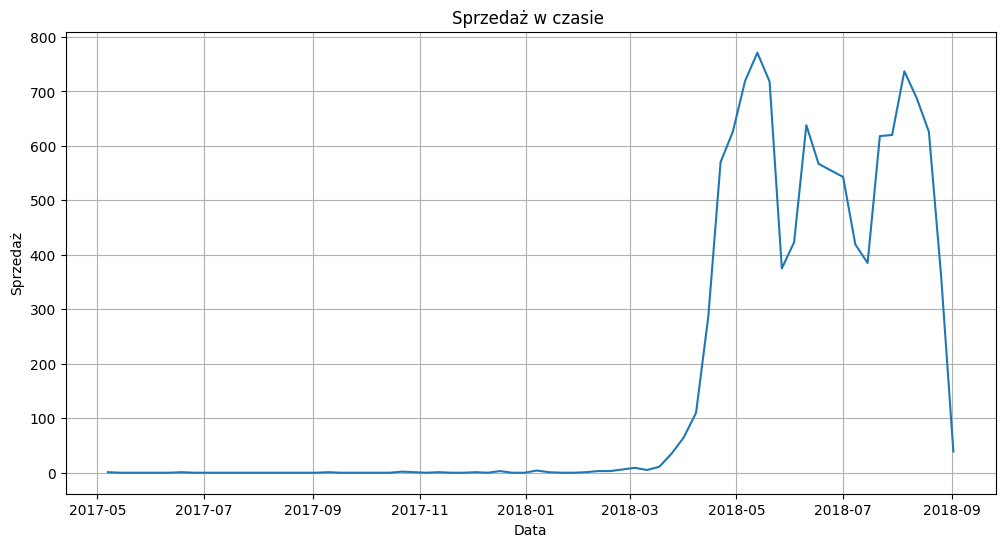

In [16]:
plt.figure(figsize=(12,6))

plt.plot(sales_time.index, sales_time.values)

plt.title("Sprzedaż w czasie ")
plt.xlabel("Data")
plt.ylabel("Sprzedaż")
plt.grid()

plt.show()

### Analiza produktów

In [17]:
df.groupby('product_category_name_english')['sales'].sum().sort_values(ascending=False)

product_category_name_english
bed_bath_table               1198
health_beauty                1104
watches_gifts                 933
housewares                    932
sports_leisure                736
                             ... 
dvds_blu_ray                    3
flowers                         1
fashion_childrens_clothes       1
cds_dvds_musicals               1
tablets_printing_image          1
Name: sales, Length: 66, dtype: int64

In [18]:
produc_sales = df.groupby('product_id')['sales'].sum()

In [19]:
produc_sales.describe()

count    6004.000000
mean        1.923551
std         3.000636
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        70.000000
Name: sales, dtype: float64

## ⚙️ ETAP 2: Feature Engineering

🔧 Tworzenie nowych cech  
🧹 Czyszczenie danych  
📊 Przygotowanie pod model

1. Agregacja do granulacji tygodniowej
2. Uzupełnienie brakujących tygodni
3. Cechy lag (opóźnione wartości)
4. Cechy rolling (średnia i std krocząca)
5. Cechy czasowe (sezonowość)
6. Target encoding kategorii + podział train/val/test

### Krok 1 — Agregacja do granulacji tygodniowej

- `week_start` = poniedziałek każdego tygodnia (`freq='W-MON'`)
- `gmv` = suma cen (ile zarobiliśmy w tym tygodniu w tej kategorii)
- `order_count` = liczba zamówień (ile sztuk sprzedanych)

In [20]:
df['week_start'] = df['order_purchase_timestamp'].dt.to_period('W').dt.start_time

df_weekly = (
    df.
    groupby(['product_category_name_english', 'week_start'])
    .agg(
        gmv = ('price', 'sum'),
        order_count = ('order_id', 'count')
    )
    .reset_index()
)

print(f"df_weekly: {df_weekly.shape}")
print(f"df_wekly zakres dat: {df_weekly['week_start'].min()} - {df_weekly['week_start'].max()}")
df_weekly.head(10)

df_weekly: (1044, 4)
df_wekly zakres dat: 2017-05-01 00:00:00 - 2018-08-27 00:00:00


,product_category_name_english,week_start,gmv,order_count
0,agro_industry_and_commerce,2018-04-16,640.00,2
1,agro_industry_and_commerce,2018-04-23,96.90,1
2,agro_industry_and_commerce,2018-05-28,465.00,1
3,agro_industry_and_commerce,2018-06-04,479.00,1
4,agro_industry_and_commerce,2018-06-11,35.00,1
5,agro_industry_and_commerce,2018-06-25,549.00,1
6,agro_industry_and_commerce,2018-07-16,76.00,1
7,agro_industry_and_commerce,2018-07-23,415.17,1
8,agro_industry_and_commerce,2018-07-30,1025.99,3
9,agro_industry_and_commerce,2018-08-13,23.90,1


### Krok 2 — Uzupełnienie brakujących tygodni zerami

In [21]:
all_weeks = df_weekly['week_start'].unique()
all_categories = df_weekly['product_category_name_english'].unique()

full_index = pd.MultiIndex.from_product(
    [all_categories, all_weeks],
    names=['product_category_name_english', 'week_start']
)

df_weekly = (
    df_weekly
    .set_index(['product_category_name_english', 'week_start'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

df_weekly = df_weekly.sort_values(['product_category_name_english', 'week_start']).reset_index(drop=True)

print(f'Kształt po uzupełnieniu: {df_weekly.shape}')
print(f'Tygodnie z GMV=0: {(df_weekly["gmv"] == 0).sum()} ({(df_weekly["gmv"] == 0).mean()*100:.1f}%)')

Kształt po uzupełnieniu: (2706, 4)
Tygodnie z GMV=0: 1662 (61.4%)


### Krok 3 — Cechy lag 

In [22]:
for lag in [1, 2, 4, 8]:
    df_weekly[f'gmv_lag_{lag}'] = (
        df_weekly.groupby('product_category_name_english')['gmv']
        .shift(lag)
    )
    df_weekly[f'count_lag_{lag}'] = (
        df_weekly.groupby('product_category_name_english')['order_count']
        .shift(lag)
    )

print('Stworzone cechy lag:')
lag_cols = [c for c in df_weekly.columns if 'lag' in c]
print(lag_cols)

przyklad = df_weekly[df_weekly['product_category_name_english'] == 'health_beauty'].head(5)
print('\nSprawdzenie (health_beauty, pierwsze 5 tygodni):')
print(przyklad[['week_start', 'gmv', 'gmv_lag_1', 'gmv_lag_2']].to_string(index=False))
print('\n→ gmv_lag_1 w wierszu 2 powinno = gmv z wiersza 1 ✓')

Stworzone cechy lag:
['gmv_lag_1', 'count_lag_1', 'gmv_lag_2', 'count_lag_2', 'gmv_lag_4', 'count_lag_4', 'gmv_lag_8', 'count_lag_8']

Sprawdzenie (health_beauty, pierwsze 5 tygodni):
week_start  gmv  gmv_lag_1  gmv_lag_2
2017-05-01  0.0        NaN        NaN
2017-06-12  0.0        0.0        NaN
2017-09-04  0.0        0.0        0.0
2017-10-16  0.0        0.0        0.0
2017-10-23  0.0        0.0        0.0

→ gmv_lag_1 w wierszu 2 powinno = gmv z wiersza 1 ✓


### Krok 4 — Cechy rolling (średnia i odchylenie krocząca)

In [23]:
for window in [4, 8, 12]:
    df_weekly[f'gmv_roll_mean_{window}'] = (
        df_weekly.groupby('product_category_name_english')['gmv']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=2).mean())
    )
    df_weekly[f'gmv_roll_std_{window}'] = (
        df_weekly.groupby('product_category_name_english')['gmv']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=2).std())
    )

# Rolling dla order_count (okna 4 i 8)
for window in [4, 8]:
    df_weekly[f'count_roll_mean_{window}'] = (
        df_weekly.groupby('product_category_name_english')['order_count']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=2).mean())
    )

roll_cols = [c for c in df_weekly.columns if 'roll' in c]
print(f'Stworzone cechy rolling ({len(roll_cols)}):') 
print(roll_cols)

Stworzone cechy rolling (8):
['gmv_roll_mean_4', 'gmv_roll_std_4', 'gmv_roll_mean_8', 'gmv_roll_std_8', 'gmv_roll_mean_12', 'gmv_roll_std_12', 'count_roll_mean_4', 'count_roll_mean_8']


### Krok 5 — Cechy czasowe (sezonowość)

In [24]:
df_weekly['week_of_year'] = df_weekly['week_start'].dt.isocalendar().week.astype(int)
df_weekly['month'] = df_weekly['week_start'].dt.month
df_weekly['quarter'] = df_weekly['week_start'].dt.quarter
df_weekly['year'] = df_weekly['week_start'].dt.year

br_holidays = [
    # Boże Narodzenie i Nowy Rok
    '2016-12-25', '2017-01-01', '2017-12-25', '2018-01-01', '2018-12-25',
    # Dzień Matki (2. niedziela maja) → silny peak sprzedaży
    '2016-05-08', '2017-05-14', '2018-05-13',
    # Karnawał
    '2017-02-27', '2017-02-28', '2018-02-12', '2018-02-13',
    # Black Friday (4. piątek listopada)
    '2016-11-25', '2017-11-24', '2018-11-23',
    # Dzień Dziecka (12 października)
    '2016-10-12', '2017-10-12', '2018-10-12',
]
br_holidays_dt = pd.to_datetime(br_holidays)


def is_holiday_week(week_start):
    week_dates = pd.date_range(week_start, periods=7)
    return int(any(h in week_dates for h in br_holidays_dt))

df_weekly['is_holiday'] = df_weekly['week_start'].apply(is_holiday_week)

print('Cechy czasowe dodane:')
print(['week_of_year', 'month', 'quarter', 'year', 'is_holiday'])
print(f'\nTygodnie ze świętem: {df_weekly["is_holiday"].sum()}')
df_weekly[['week_start', 'week_of_year', 'month', 'quarter', 'is_holiday']].drop_duplicates().head(10)

Cechy czasowe dodane:
['week_of_year', 'month', 'quarter', 'year', 'is_holiday']

Tygodnie ze świętem: 198


,week_start,week_of_year,month,quarter,is_holiday
0,2017-05-01,18,5,2,0
1,2017-06-12,24,6,2,0
2,2017-09-04,36,9,3,0
3,2017-10-16,42,10,4,0
4,2017-10-23,43,10,4,0
5,2017-11-06,45,11,4,0
6,2017-11-27,48,11,4,0
7,2017-12-11,50,12,4,0
8,2018-01-01,1,1,1,1
9,2018-01-08,2,1,1,0


### Krok 6 — Target encoding + podział train/val/test

In [25]:
import numpy as np

# ── Podział chronologiczny ──────────────────────────────────────
train_mask = df_weekly['week_start'] <= '2017-12-31'
val_mask   = (df_weekly['week_start'] > '2017-12-31') & (df_weekly['week_start'] <= '2018-06-30')
test_mask  = df_weekly['week_start'] > '2018-06-30'

print('Rozmiary zbiorów:')
print(f'  train : {train_mask.sum():>6} wierszy  '
      f'({df_weekly.loc[train_mask, "week_start"].min().date()} → '
      f'{df_weekly.loc[train_mask, "week_start"].max().date()})')
print(f'  val   : {val_mask.sum():>6} wierszy  '
      f'({df_weekly.loc[val_mask, "week_start"].min().date()} → '
      f'{df_weekly.loc[val_mask, "week_start"].max().date()})')
print(f'  test  : {test_mask.sum():>6} wierszy  '
      f'({df_weekly.loc[test_mask, "week_start"].min().date()} → '
      f'{df_weekly.loc[test_mask, "week_start"].max().date()})')

# ── Target encoding — TYLKO na trainie ─────────────────────────
target_enc_map = (
    df_weekly.loc[train_mask]
    .groupby('product_category_name_english')['gmv']
    .mean()
    .rename('category_mean_gmv')
)

# Nakładamy tę samą mapę na cały df (train + val + test)
df_weekly = df_weekly.join(target_enc_map, on='product_category_name_english')

print(f'\nTarget encoding — top 5 kategorii wg średniego GMV:')
print(target_enc_map.sort_values(ascending=False).head())

Rozmiary zbiorów:
  train :    528 wierszy  (2017-05-01 → 2017-12-11)
  val   :   1584 wierszy  (2018-01-01 → 2018-06-25)
  test  :    594 wierszy  (2018-07-02 → 2018-08-27)

Target encoding — top 5 kategorii wg średniego GMV:
product_category_name_english
sports_leisure           69.86000
art                      37.49875
bed_bath_table           14.98750
computers_accessories    12.37500
toys                     10.87375
Name: category_mean_gmv, dtype: float64


### Krok 7 — Definicja cech i finalne zbiory

In [26]:
from sklearn.preprocessing import LabelEncoder

# Label encoding kategorii (string → liczba)
le = LabelEncoder()
df_weekly['category_enc'] = le.fit_transform(df_weekly['product_category_name_english'])

# Lista cech do modelu
FEATURES = [
    # lagi gmv
    'gmv_lag_1', 'gmv_lag_2', 'gmv_lag_4', 'gmv_lag_8',
    # lagi count
    'count_lag_1', 'count_lag_2', 'count_lag_4', 'count_lag_8',
    # rolling gmv
    'gmv_roll_mean_4', 'gmv_roll_mean_8', 'gmv_roll_mean_12',
    'gmv_roll_std_4',  'gmv_roll_std_8',  'gmv_roll_std_12',
    # rolling count
    'count_roll_mean_4', 'count_roll_mean_8',
    # czas
    'week_of_year', 'month', 'quarter', 'year', 'is_holiday',
    # kategoria
    'category_enc', 'category_mean_gmv',
]

TARGET = 'gmv'

# Usuń wiersze z NaN w cechach (pierwsze tygodnie nie mają lagów)
df_model = df_weekly.dropna(subset=FEATURES + [TARGET]).copy()

print(f'df_weekly → {df_weekly.shape}')
print(f'df_model (po usunięciu NaN) → {df_model.shape}')
print(f'Usunięto wierszy z NaN: {len(df_weekly) - len(df_model)}')
print(f'\nLiczba cech: {len(FEATURES)}')

# Zbuduj finalne X i y
X_train = df_model.loc[train_mask.reindex(df_model.index, fill_value=False), FEATURES]
y_train = df_model.loc[train_mask.reindex(df_model.index, fill_value=False), TARGET]

X_val   = df_model.loc[val_mask.reindex(df_model.index, fill_value=False), FEATURES]
y_val   = df_model.loc[val_mask.reindex(df_model.index, fill_value=False), TARGET]

X_test  = df_model.loc[test_mask.reindex(df_model.index, fill_value=False), FEATURES]
y_test  = df_model.loc[test_mask.reindex(df_model.index, fill_value=False), TARGET]

print(f'\nFinalne zbiory:')
print(f'  X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'  X_val:   {X_val.shape}  y_val:   {y_val.shape}')
print(f'  X_test:  {X_test.shape}  y_test:  {y_test.shape}')

df_weekly → (2706, 27)
df_model (po usunięciu NaN) → (2178, 27)
Usunięto wierszy z NaN: 528

Liczba cech: 23

Finalne zbiory:
  X_train: (0, 23)  y_train: (0,)
  X_val:   (1584, 23)  y_val:   (1584,)
  X_test:  (594, 23)  y_test:  (594,)


### Krok 8 — Podgląd finalnego zbioru i zapis

Ostatni krok — sprawdzamy czy wszystko wygląda dobrze i zapisujemy `df_model` do pliku. Etap 3 (model) wczyta ten plik jako punkt startowy.

In [27]:
import os

# Podsumowanie cech
print('=== PODSUMOWANIE ETAPU 2 ===')
print(f'Liczba kategorii:   {df_model["product_category_name_english"].nunique()}')
print(f'Liczba tygodni:     {df_model["week_start"].nunique()}')
print(f'Liczba cech:        {len(FEATURES)}')
print(f'Wierszy w df_model: {len(df_model)}')
print(f'\nStatystyki targetu (GMV):')
print(df_model[TARGET].describe().round(2))

# Sprawdź czy są NaN w cechach
nan_check = X_train.isna().sum()
if nan_check.sum() == 0:
    print('\n✓ Brak NaN w X_train — gotowe do modelowania!')
else:
    print('\n⚠ NaN w X_train:')
    print(nan_check[nan_check > 0])

# Zapis
os.makedirs('dane/processed', exist_ok=True)
df_model.to_parquet('dane/processed/df_model.parquet', index=False)
print('\nZapisano: dane/processed/df_model.parquet')
print('→ Ten plik jest wejściem do Etapu 3 (Model)')

=== PODSUMOWANIE ETAPU 2 ===
Liczba kategorii:   66
Liczba tygodni:     33
Liczba cech:        23
Wierszy w df_model: 2178

Statystyki targetu (GMV):
count     2178.00
mean       694.03
std       1672.43
min          0.00
25%          0.00
50%          0.00
75%        480.16
max      16278.44
Name: gmv, dtype: float64

✓ Brak NaN w X_train — gotowe do modelowania!

Zapisano: dane/processed/df_model.parquet
→ Ten plik jest wejściem do Etapu 3 (Model)


In [28]:
!pip install pyarrow

## 🤖 ETAP 3: Model

📌 Budowa i trenowanie modelu predykcyjnego

🔧 Wybór algorytmu  
📊 Trenowanie modelu  
🎯 Ewaluacja (MAE / RMSE / Accuracy)  
📈 Feature importance

## 📦 ETAP 4: Trendy i stany magazynowe

📌 Analiza sprzedaży i wsparcie decyzji logistycznych

📈 Trendy sprzedaży w czasie  
🔁 Sezonowość  
🚨 Wykrywanie pików (np. Black Friday)  
📦 Estymacja zapotrzebowania / stock levels

## 🌐 ETAP 5: Aplikacja webowa

📌 Udostępnienie modelu i wyników w formie aplikacji

🧠 Integracja modelu  
📊 Dashboard (wykresy, metryki)  
⚡ API / Streamlit / Flask  
👤 Interakcja użytkownika